In [ ]:
pip install imbalanced-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from collections import Counter
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN



In [1]:
import os
print(os.getcwd())                                    # folder the notebook runs from
print([f for f in os.listdir() if f.endswith(".csv")])  # CSVs in that folder

c:\Users\adith\OneDrive\Documents\Academics_SCIT_Books\OROT\Academics_SCIT_Books\Fraud_Analytics
[]


In [4]:
df = pd.read_csv("customers-10000.csv")

In [5]:
print(list(df.columns))

['Index', 'Customer Id', 'First Name', 'Last Name', 'Company', 'City', 'Country', 'Phone 1', 'Phone 2', 'Email', 'Subscription Date', 'Website']


# Partition

In [5]:
split_fraction = 0.70
partition = df.sample(frac=split_fraction, random_state=42)
len(partition)

7000

# Random 

In [6]:
sample_random = df.sample(n=100)
sample_random.head()

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
5670,5671,caBc788e17DeBAe,Frank,Winters,Day Inc,Lake Alexaland,Fiji,001-485-916-9460x0223,931.443.6398x5895,ldunlap@washington-mckenzie.com,2021-03-03,http://parks.com/
38,39,ec75Fb9C6A0DcF1,Joyce,Foster,Randolph LLC,Nataliestad,Korea,655.928.6486,+1-966-669-6464,samuel97@wyatt.com,2020-10-29,https://www.schmitt.com/
9573,9574,bB8502cdEFFc5f8,Jeanne,Salas,"Hurley, Lang and Wells",Peggybury,Tunisia,113-204-6400,774.855.5950x11404,hutchinsonwendy@kelley.com,2020-01-11,http://hahn.com/
4241,4242,d8cb2fFB01e638E,Joyce,Ramirez,Townsend-Christian,South Roberto,Comoros,822.646.7809x85533,947-795-5072,summermelendez@conway.biz,2021-05-12,https://www.le-frederick.info/
7986,7987,B1Cbd3b8810b78c,Natasha,Kidd,Hill-Hendricks,East Haydenville,Tuvalu,852-220-0484,001-372-352-4399,patelshannon@wyatt.info,2022-01-22,https://daugherty.com/


# stratified

In [7]:
sample_stratified = (
    df.groupby("Country")
      .apply(lambda x: x.sample(frac=0.1))
)
sample_stratified.head()
#sample_stratified.count()
#print(sample_stratified["Country"].value_counts())

Index      Customer Id First Name  Last Name  \
Country                                                          
Afghanistan 2374   2375  aF294aE75f4fe3c    Russell    Stevens   
            9088   9089  bfc3B455Dd2f4bd     Sophia    Schultz   
            2387   2388  17f1B041b0bc58B     Albert  Mcfarland   
            1610   1611  580a5AA0D534e6e     Justin  Mcpherson   
Albania     8684   8685  13B7bAEBB251dd0   Mitchell     Dennis   

                                            Company                  City  \
Country                                                                     
Afghanistan 2374                         Reese-Hale          Cesarchester   
            9088                    Brooks and Sons  North Maureenchester   
            2387                         Mathis PLC          South Mariah   
            1610  Donaldson, Dougherty and Holloway           West Mathew   
Albania     8684         Keith, Copeland and Conner           Molinaburgh   

                                Phone 1                 Phone 2  \
Country                                                           
Afghanistan 2374  001-985-857-3866x1896              5092084934   
            9088      355.104.4169x7569        370-557-8403x676   
            2387   001-774-583-0062x287    001-607-235-1597x718   
            1610  +1-982-274-5504x12756  001-173-087-7818x48484   
Albania     8684             4800699477   +1-378-293-6209x87644   

                                               Email Subscription Date  \
Country                                                                  
Afghanistan 2374             newtonjeffery@crane.com        2021-01-27   
            9088              lucasweeks@carter.info        2021-10-04   
            2387                 qburke@alvarado.com        2020-10-22   
            1610            doriswilkins@ramirez.org        2022-04-19   
Albania     8684  lorraineschaefer@norman-larson.org        2021-05-21   

                                   Website  
Country                                     
Afghanistan 2374        http://ayers.info/  
            9088   http://www.hubbard.biz/  
            2387  https://www.stanton.com/  
            1610   http://leon-flores.com/  
Albania     8684          http://bond.biz/

In [8]:
# Task 1: Stratified sample with a FIXED size of 500 rows
# Proportional allocation: each country gets a share of 500 matching its share in df.
# Largest-remainder rounding makes the total exactly 500.
n_total = 500

props = df["Country"].value_counts(normalize=True) * n_total
alloc = np.floor(props).astype(int)
remaining = n_total - alloc.sum()
top_up = (props - alloc).sort_values(ascending=False).index[:remaining]
alloc[top_up] += 1

sample_500 = pd.concat([
    df[df["Country"] == country].sample(n=k, random_state=42)
    for country, k in alloc.items() if k > 0
])

print("Sample size:", len(sample_500))
sample_500.head()

Sample size: 500


,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
8542,8543,3f8f26799a8aA42,Cassidy,Bush,Pittman LLC,Tylerland,Korea,9523568511,001-291-424-6590x7698,wooddarlene@stout.com,2020-07-03,http://www.turner.net/
38,39,ec75Fb9C6A0DcF1,Joyce,Foster,Randolph LLC,Nataliestad,Korea,655.928.6486,+1-966-669-6464,samuel97@wyatt.com,2020-10-29,https://www.schmitt.com/
6446,6447,eAF3e0D500E11BC,Kristopher,Olsen,Warner-Moreno,Mirandaburgh,Korea,(916)783-4149,001-179-161-9291,wallacefernando@olsen.biz,2021-01-27,http://eaton.net/
2706,2707,e1Ee301D7d6ac1e,Shane,Holloway,Davila-Trujillo,West Reginald,Korea,116-124-8781x69177,(784)179-4826,fritzgabrielle@hebert.biz,2021-04-01,https://www.barajas.org/
4062,4063,CE9D0E219069CA0,Kristina,Le,Arroyo-Giles,Lake Hayley,Congo,(633)812-8183,196.376.3904x827,marilyn25@cardenas.info,2020-05-22,https://www.castaneda-everett.com/


In [9]:
# Task 2: Country-wise list / count of the 500-row sample
country_counts = sample_500["Country"].value_counts()
print("Number of countries in sample:", country_counts.shape[0])

# Compare sample share vs population share (they should be close -> stratification worked)
compare = pd.DataFrame({
    "population_count": df["Country"].value_counts(),
    "sample_count": country_counts,
}).fillna(0).astype(int)
compare["population_%"] = (compare["population_count"] / len(df) * 100).round(2)
compare["sample_%"] = (compare["sample_count"] / len(sample_500) * 100).round(2)
compare.sort_values("population_count", ascending=False).head(20)

Number of countries in sample: 243


,population_count,sample_count,population_%,sample_%
Country,,,,
Korea,84,4,0.84,0.8
Congo,81,4,0.81,0.8
Vanuatu,58,3,0.58,0.6
Sierra Leone,56,3,0.56,0.6
Montenegro,54,3,0.54,0.6
Cote d'Ivoire,54,3,0.54,0.6
United States Virgin Islands,54,3,0.54,0.6
Mauritius,54,3,0.54,0.6
Andorra,54,3,0.54,0.6


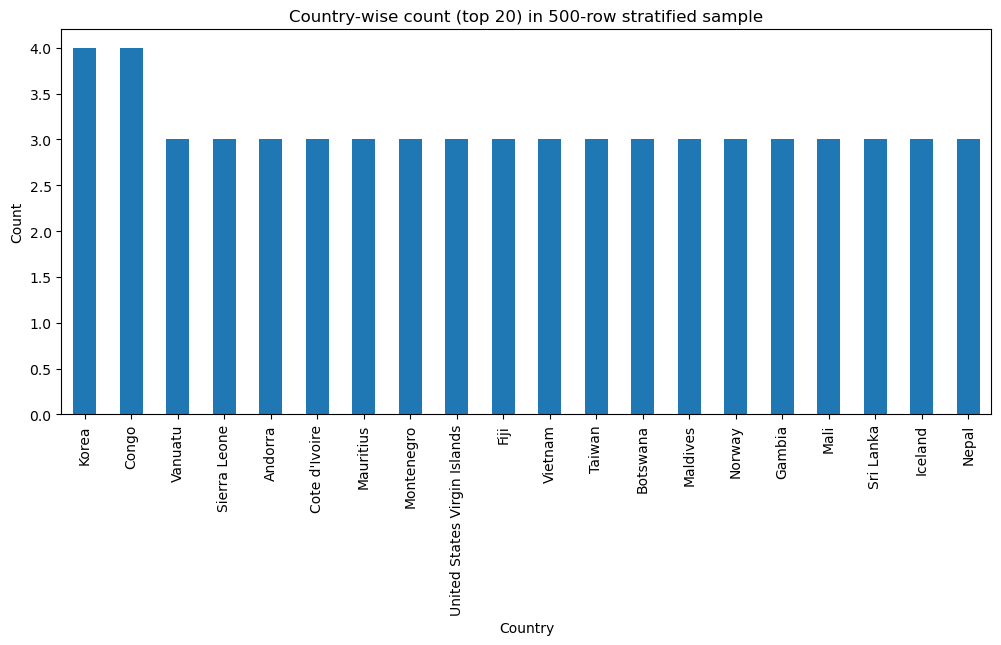

In [10]:
# Bar chart of the top 20 countries in the sample
country_counts.head(20).plot(kind="bar", figsize=(12, 5))
plt.title("Country-wise count (top 20) in 500-row stratified sample")
plt.ylabel("Count")
plt.show()

In [11]:
# Task 3: Equalize the country-wise count
# Option A - Undersampling: every country gets the same n = size of the smallest country
min_count = df["Country"].value_counts().min()
sample_equal = df.groupby("Country").sample(n=min_count, random_state=42)

print("Rows per country:", min_count)
print("Total rows:", len(sample_equal))
print(sample_equal["Country"].value_counts().describe())   # min = max -> equalized

Rows per country: 26
Total rows: 6318
count    243.0
mean      26.0
std        0.0
min       26.0
25%       26.0
50%       26.0
75%       26.0
max       26.0
Name: count, dtype: float64


In [12]:
# Option B - Oversampling: duplicate rows of smaller countries up to the largest country
ros = RandomOverSampler(random_state=42)
X_eq, y_eq = ros.fit_resample(df.drop(columns="Country"), df["Country"])
sample_equal_over = X_eq.assign(Country=y_eq)

print("Before:", Counter(df["Country"]).most_common(3), "...")
print("After :", Counter(sample_equal_over["Country"]).most_common(3), "...")
print("Total rows after oversampling:", len(sample_equal_over))

Before: [('Korea', 84), ('Congo', 81), ('Vanuatu', 58)] ...
After : [('Norway', 84), ('Andorra', 84), ('Nepal', 84)] ...
Total rows after oversampling: 20412


# Cluster 

In [13]:
countries = df["Country"].unique()
selected_countries = pd.Series(countries).sample(n=2, random_state=42)
sample_cluster = df[df["Country"].isin(selected_countries)]
sample_cluster.head(36)
#sample_cluster.count()

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
6,7,3e1187fCcebC8d2,Mathew,Hoffman,"Bender, Pittman and Kidd",West Ralph,Uzbekistan,842.380.1168,(178)178-5447x32603,bauergerald@morrison.com,2020-04-09,http://www.holt.com/
25,26,0748BdEFeb4834F,Mackenzie,Williamson,Hart-Klein,New Maxhaven,Saint Helena,+1-605-640-1833x70183,656.931.4990,zramos@haney.org,2020-03-06,http://www.allison-clements.com/
78,79,e8f4b4D1FcF5Fc3,Joshua,Ortega,"Herman, Preston and Spence",Lake Brittney,Uzbekistan,+1-734-076-1901x55246,001-569-506-8227,robbinsgordon@dyer-kim.info,2021-09-29,http://barr-salas.org/
146,147,BffD8b78EB17aB6,Diamond,Pollard,Hull Group,North Isabellaberg,Uzbekistan,3816437019,614.140.7737x97774,weavermeagan@sampson.com,2020-03-02,https://fox.biz/
170,171,65EfcbFAaBc9755,Steve,Booth,"Cooke, Zuniga and Maldonado",North Glendaborough,Saint Helena,(390)652-3650x10148,995.423.9151x965,perry87@nichols.biz,2021-10-12,https://molina.com/
280,281,Aaf2D8fF5edeD6F,Evelyn,Huynh,Parrish-Simmons,South Sheila,Saint Helena,001-650-421-0322x71656,224.261.4291,jmullins@craig.com,2022-03-23,http://www.ellison-hobbs.com/
583,584,1A6D0cd74F67a5a,Stanley,Shannon,Tucker-Diaz,Laurabury,Saint Helena,9042616723,+1-049-516-0935x212,becky23@nunez.info,2021-09-23,http://frey-rowland.net/
746,747,cf4DAA75cd7AC14,Betty,Soto,Roberson PLC,South Guy,Uzbekistan,3719042212,434-533-6969x900,lcooper@ball-pittman.org,2020-08-29,http://patterson-huerta.com/
854,855,6CFAA9f71E9423B,Judy,Rogers,Meyers and Sons,Cliffordborough,Saint Helena,(181)997-7317,+1-610-634-3284x8288,vernon50@dennis.biz,2021-04-10,http://davenport-jefferson.com/
1046,1047,bb53513a2648c5f,Yvonne,Kramer,"Fleming, Bryan and Pruitt",New Fred,Uzbekistan,001-451-673-4313x2831,+1-344-126-1653x54520,adrienneescobar@krueger.biz,2022-04-02,https://www.benton-escobar.info/


In [14]:
# Task 4: Sample from the 5 most and 5 least listed countries
counts = df["Country"].value_counts()
top5 = counts.head(5).index.tolist()
bottom5 = counts.tail(5).index.tolist()
print("5 most listed :", counts.head(5).to_dict())
print("5 least listed:", counts.tail(5).to_dict())

n_per_country = 10   # rows to sample from each selected country

sample_top5 = (df[df["Country"].isin(top5)]
               .groupby("Country")
               .sample(n=n_per_country, random_state=42))

# least-listed countries may have fewer rows than n_per_country -> take what exists
sample_bottom5 = pd.concat([
    g.sample(n=min(n_per_country, len(g)), random_state=42)
    for _, g in df[df["Country"].isin(bottom5)].groupby("Country")
])

print("\nTop-5 sample:", sample_top5["Country"].value_counts().to_dict())
print("Bottom-5 sample:", sample_bottom5["Country"].value_counts().to_dict())

5 most listed : {'Korea': 84, 'Congo': 81, 'Vanuatu': 58, 'Sierra Leone': 56, 'Andorra': 54}
5 least listed: {'Suriname': 27, 'Palestinian Territory': 26, 'Mayotte': 26, 'New Caledonia': 26, 'Antarctica (the territory South of 60 deg S)': 26}

Top-5 sample: {'Andorra': 10, 'Congo': 10, 'Korea': 10, 'Sierra Leone': 10, 'Vanuatu': 10}
Bottom-5 sample: {'Antarctica (the territory South of 60 deg S)': 10, 'Mayotte': 10, 'New Caledonia': 10, 'Palestinian Territory': 10, 'Suriname': 10}


In [ ]:
#Data Selection

# Data Selection (on the fraud dataset)
`customers-10000.csv` has no fraud label and almost no numeric columns, so correlation, chi-square and the ML model are done on the fraud dataset (`Fraudulent` is the target).

In [15]:
df_f = pd.read_csv("Fraud Detection Dataset.csv")
target = "Fraudulent"
print(df_f.shape)
df_f.head()

(51000, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [16]:
# 1. Missing values: % missing per column; drop columns that are mostly empty
missing_pct = (df_f.isnull().mean() * 100).sort_values(ascending=False)
print(missing_pct)

threshold = 40   # drop a column if more than 40% is missing
drop_missing = missing_pct[missing_pct > threshold].index.tolist()
print("Columns dropped for missing values:", drop_missing)
df_f = df_f.drop(columns=drop_missing)
# Remaining gaps are imputed later inside the pipeline (median / most frequent)

Time_of_Transaction                 5.003922
Location                            4.994118
Transaction_Amount                  4.941176
Device_Used                         4.849020
Payment_Method                      4.841176
Transaction_Type                    0.000000
Transaction_ID                      0.000000
User_ID                             0.000000
Previous_Fraudulent_Transactions    0.000000
Account_Age                         0.000000
Number_of_Transactions_Last_24H     0.000000
Fraudulent                          0.000000
dtype: float64
Columns dropped for missing values: []


In [17]:
# 2. Identical values
# (a) duplicate rows
print("Duplicate rows:", df_f.duplicated().sum())
df_f = df_f.drop_duplicates()

# (b) constant / near-constant columns (one value in >= 95% of rows) carry no information
top_share = df_f.apply(lambda s: s.value_counts(normalize=True, dropna=False).iloc[0])
near_constant = top_share[top_share >= 0.95].index.drop(target, errors="ignore").tolist()

# (c) identifier columns (a different value in almost every row) - they can't generalize
id_like = [c for c in df_f.columns if df_f[c].nunique() > 0.9 * len(df_f) and not pd.api.types.is_numeric_dtype(df_f[c])]
id_like += [c for c in ["Transaction_ID", "User_ID"] if c in df_f.columns and c not in id_like]

print("Near-constant columns:", near_constant)
print("ID-like columns:", id_like)
df_f = df_f.drop(columns=near_constant + id_like)
print("Remaining columns:", list(df_f.columns))

Duplicate rows: 881
Near-constant columns: []
ID-like columns: ['Transaction_ID', 'User_ID']
Remaining columns: ['Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']


Correlation with target:
Number_of_Transactions_Last_24H    -0.003964
Previous_Fraudulent_Transactions    0.000766
Account_Age                         0.005517
Transaction_Amount                  0.005800
Time_of_Transaction                 0.005854
Name: Fraudulent, dtype: float64


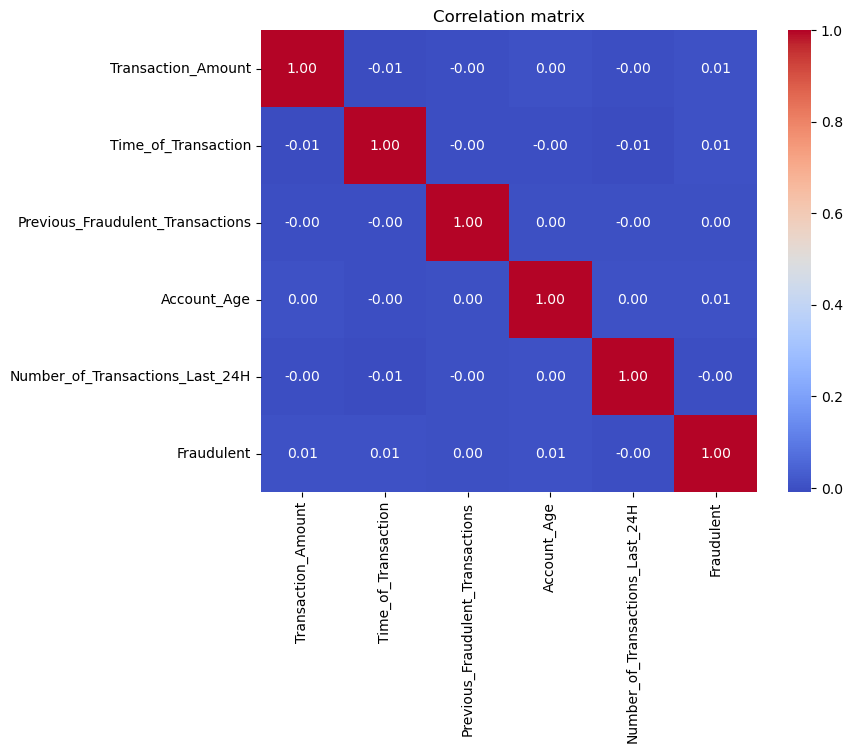

Redundant numeric features: []


In [18]:
# 3. Correlation analysis (numeric features vs the target, and with each other)
corr = df_f.corr(numeric_only=True)
print("Correlation with target:")
print(corr[target].drop(target).sort_values())

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

# Highly correlated feature pairs (|r| > 0.8) are redundant -> keep only one of each pair
upper = corr.drop(index=target, columns=target).abs()
upper = upper.where(np.triu(np.ones(upper.shape, dtype=bool), k=1))
redundant = [c for c in upper.columns if (upper[c] > 0.8).any()]
print("Redundant numeric features:", redundant)

In [19]:
# 4. Chi-square test (categorical features vs the target)
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.preprocessing import OrdinalEncoder

cat_cols = df_f.select_dtypes(exclude="number").columns.tolist()
chi_df = df_f[cat_cols + [target]].dropna()

# chi2 needs non-negative numbers -> encode categories as integer codes
X_cat = OrdinalEncoder().fit_transform(chi_df[cat_cols])
y_cat = chi_df[target]

selector = SelectKBest(score_func=chi2, k="all")
selector.fit(X_cat, y_cat)

chi_result = pd.DataFrame({
    "feature": cat_cols,
    "chi2_score": selector.scores_,
    "p_value": selector.pvalues_,
}).sort_values("chi2_score", ascending=False)
chi_result["significant (p<0.05)"] = chi_result["p_value"] < 0.05
chi_result

,feature,chi2_score,p_value,significant (p<0.05)
2,Location,4.762281,0.029090,True
0,Transaction_Type,2.310138,0.128533,False
1,Device_Used,0.063702,0.800738,False
3,Payment_Method,0.009038,0.924260,False


In [20]:
# Split: features / target, then a stratified 70:30 train-test split
X = df_f.drop(columns=[target] + redundant)
Y = df_f[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, stratify=Y, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Fraud rate train / test:", round(y_train.mean(), 4), "/", round(y_test.mean(), 4))

Train: (35083, 9) Test: (15036, 9)
Fraud rate train / test: 0.0492 / 0.0492


Task 5: 
ML Model

In [21]:
# Task 5: ML models
# Preprocessing: impute + scale numeric, impute + one-hot categorical.
# SMOTE is applied ONLY to the training data inside the pipeline (no leakage into the test set).
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), num_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
}

fitted = {}
for name, model in models.items():
    pipe = ImbPipeline([
        ("prep", preprocess),
        ("smote", SMOTE(random_state=42)),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    print("Trained:", name)

Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest


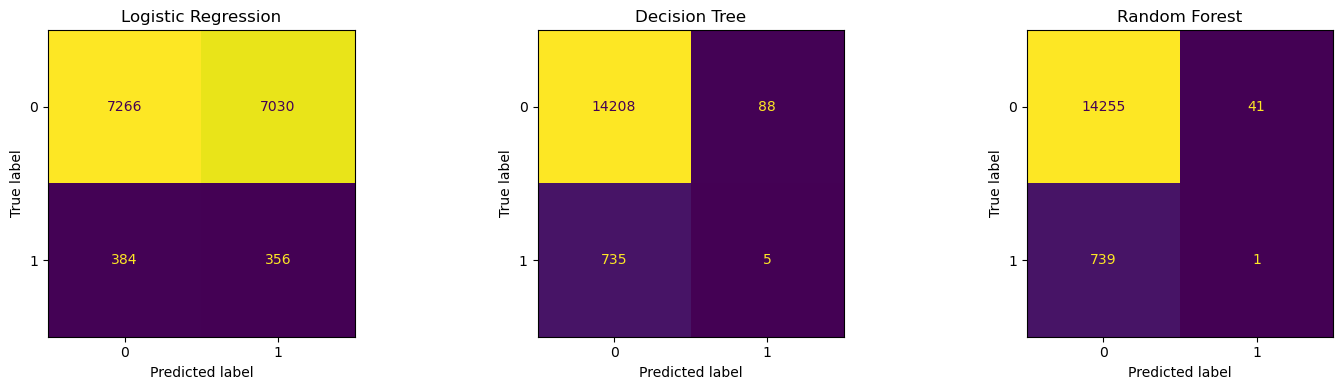

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
Random Forest,0.948,0.024,0.001,0.003,0.514,0.052
Logistic Regression,0.507,0.048,0.481,0.088,0.494,0.048
Decision Tree,0.945,0.054,0.007,0.012,0.489,0.048


In [22]:
# Result Analysis
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score)

rows = []
fig, axes = plt.subplots(1, len(fitted), figsize=(5 * len(fitted), 4))
for ax, (name, pipe) in zip(axes, fitted.items()):
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob),
    })
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

results = pd.DataFrame(rows).set_index("Model").round(3)
results.sort_values("PR-AUC", ascending=False)

Best model: Random Forest
              precision    recall  f1-score   support

           0      0.951     0.997     0.973     14296
           1      0.024     0.001     0.003       740

    accuracy                          0.948     15036
   macro avg      0.487     0.499     0.488     15036
weighted avg      0.905     0.948     0.926     15036



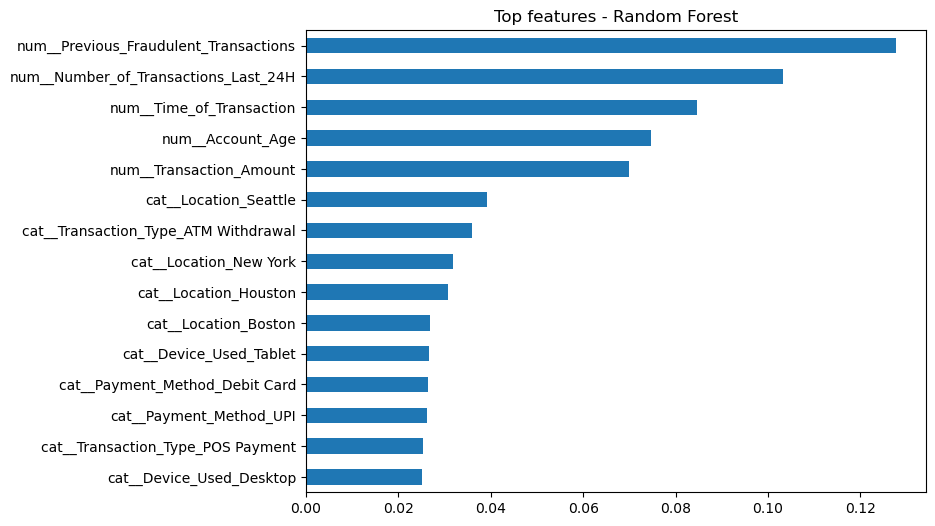

In [23]:
# Detailed report for the best model (by PR-AUC, the most honest metric for rare fraud)
best = results["PR-AUC"].idxmax()
print("Best model:", best)
print(classification_report(y_test, fitted[best].predict(X_test), digits=3))

# Feature importance (tree models) - which features drive fraud predictions
if hasattr(fitted[best].named_steps["model"], "feature_importances_"):
    names = fitted[best].named_steps["prep"].get_feature_names_out()
    imp = pd.Series(fitted[best].named_steps["model"].feature_importances_, index=names)
    imp.sort_values().tail(15).plot(kind="barh", figsize=(8, 6), title=f"Top features - {best}")
    plt.show()

**How to read the results**
- Fraud is rare, so **accuracy is misleading** (predicting "not fraud" for everything already scores high). Compare models on **Recall** (share of frauds caught), **Precision** (share of alerts that are real fraud), **F1** and **PR-AUC**.
- ROC-AUC near 0.5 means the model is no better than guessing; write that down honestly if it happens - it says the available features don't separate fraud well.
- Use the confusion matrix to discuss the cost trade-off: false negatives (missed fraud) vs false positives (genuine customers blocked).